# Notebook 02 - Data Preparation and Segmentation Readiness EDA

This notebook turns the raw source tables into the clean transaction dataset and evaluates whether Carrefour basket behaviour contains enough product-led structure to support organic customer segmentation.

## Table of Contents
- [2.0 Setup and Imports](#20-setup-and-imports)
- [2.1 Data Inventory](#21-data-inventory)
- [2.2 Data Quality Gates](#22-data-quality-gates)
- [2.3 Merge and Clean Transaction Dataset](#23-merge-and-clean-transaction-dataset)
- [2.4 Product Landscape and Demand Concentration](#24-product-landscape-and-demand-concentration)
- [2.5 Basket Structure and Co-Purchase Patterns](#25-basket-structure-and-co-purchase-patterns)
- [2.6 Product Timing and Shopping Context](#26-product-timing-and-shopping-context)
- [2.7 Customer-Product Recurrence](#27-customer-product-recurrence)
- [2.8 Customer Behavioural Spread](#28-customer-behavioural-spread)
- [2.9 Promo, Store and Revenue Context](#29-promo-store-and-revenue-context)
- [2.10 Segmentation Viability Assessment](#210-segmentation-viability-assessment)
- [2.11 EDA Summary](#211-eda-summary)
- [2.12 Dev Subset Generation and Handoff](#212-dev-subset-generation-and-handoff)

<a id="20-setup-and-imports"></a>
## 2.0 Setup and Imports

Load notebook dependencies, configure paths, and prepare shared output folders.

In [1]:
# Section 0 — Setup & Imports
import sys, warnings
from pathlib import Path
sys.path.append(str(Path.cwd().parent))
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl

from src.config import DATA_PROCESSED, OUTPUTS, SAMPLE_SIZE
from src.data_loader import load_maestra_articulos, load_linea_tickets

OUTPUTS.mkdir(parents=True, exist_ok=True)
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
print("imports OK")

from src.config import MODE
print(MODE)

imports OK
prod


<a id="21-data-inventory"></a>
## 2.1 Data Inventory

Confirm source table scale, schema, coverage, and product catalogue context before applying quality gates.

In [2]:
# product master — ~893k product SKUs with sector labels
df_articles = load_maestra_articulos()

print(f"Shape: {df_articles.shape[0]:,} rows × {df_articles.shape[1]} cols")
print(f"Columns: {df_articles.columns}")

print("\nProducts per sector:")
print(
    df_articles.group_by(["idsector", "desc_sector"])
               .agg(pl.len().alias("n_products"))
               .sort("n_products", descending=True)
)
df_articles.head()

Shape: 893,944 rows × 4 cols
Columns: ['idarticu', 'desc_larga_articulo', 'idsector', 'desc_sector']

Products per sector:
shape: (6, 3)
┌──────────┬──────────────────────┬────────────┐
│ idsector ┆ desc_sector          ┆ n_products │
│ ---      ┆ ---                  ┆ ---        │
│ i64      ┆ str                  ┆ u32        │
╞══════════╪══════════════════════╪════════════╡
│ 3        ┆ BAZAR                ┆ 425050     │
│ 1        ┆ P.G.C.               ┆ 171672     │
│ 6        ┆ TEXTIL               ┆ 132735     │
│ 2        ┆ PROD. FRESCOS TRADIC ┆ 88033      │
│ 4        ┆ ELECTROFOTO          ┆ 75979      │
│ 7        ┆ GASOLINERA           ┆ 475        │
└──────────┴──────────────────────┴────────────┘


idarticu,desc_larga_articulo,idsector,desc_sector
i64,str,i64,str
966557,"""GUISO DE VERDURAS LITORAL 415 …",1,"""P.G.C."""
909163,"""LA HISTORIA DE LOS 3 CERDITOS …",3,"""BAZAR"""
594029,"""MUU (SUSAETA)""",3,"""BAZAR"""
86412,"""ALAS DE MOSCA PARA ÃNGEL ANAY…",3,"""BAZAR"""
507503,"""CAMISETA NINO MANGA LARGA SPID…",6,"""TEXTIL"""


In [3]:
# transaction lines — lazy frame over the full 191M-row dataset (never fully materialised)
df_tickets = load_linea_tickets()

# row count: this executes a count, but does not materialize all rows
n_rows = df_tickets.select(pl.len().alias("n_rows")).collect().item()
print("Number of rows:", n_rows)

# column names
cols = df_tickets.collect_schema().names()
print("Columns:", cols[:])

df_tickets.limit(5).collect().with_row_index("row_number")


Number of rows: 191017715
Columns: ['idempres', 'fecha', 'hora', 'ticket', 'cliente', 'idarticu', 'unidades', 'importe', 'idpromoc', 'idtiprod']


row_number,idempres,fecha,hora,ticket,cliente,idarticu,unidades,importe,idpromoc,idtiprod
u32,i64,date,i64,str,str,i64,i64,f64,str,i64
0,7,2022-01-27,1921,"""2022-01-2700250025022004292""","""f228d04042276bdce9881998562b10…",819748,2,3.64,"""Promo""",2
1,7,2022-06-20,2046,"""2022-06-2000500050035008680""","""b0b59dac05c99607453446fbc83e9e…",507244,1,2.1,"""No promo""",1
2,7,2022-05-19,1824,"""2022-05-1900990099005008383""","""7a253da3aceb4cedd07c3b0b7d9e6b…",649683,1,1.45,"""No promo""",1
3,7,2022-03-26,1146,"""2022-03-2600700070019007694""","""f98195913fef2b5b4a4f95422cce51…",65358,1,2.61,"""Promo""",2
4,2,2022-02-13,1851,"""2022-02-1368186818154003632""","""37b896c5d0c3bcb141ff0bb17ee924…",261966,1,1.01,"""No promo""",1


<a id="22-data-quality-gates"></a>
## 2.2 Data Quality Gates

Run hard data-quality checks before feature engineering so the segmentation pipeline is not built on artefacts.

In [4]:
from src.data_quality import (
    validate_schema, audit_nulls, audit_anomalies,
    check_product_coverage, check_temporal_completeness,
    audit_customer_activity, audit_promotional_data,
    audit_stores, build_quality_report,
)

# Loads quality_report.json from cache if it exists — no parquet scans needed.
# Pass force=True to re-run all 6 streaming scans (e.g. after raw data changes).
report = build_quality_report(verbose=True)

Loaded quality report from cache (C:\Users\sebog\proyectos\carrefour_capstone\data\processed\quality_report.json)
  8/8 checks passed — pass force=True to re-run scans


In [5]:
# Anomaly detail: understand scale of returns / bad data
import json

try:
    ROOT
except NameError:
    from src.config import ROOT

PROD_PROCESSED = ROOT / "data" / "processed"

if "report" not in globals():
    quality_report_path = PROD_PROCESSED / "quality_report.json"
    if quality_report_path.exists():
        report = json.loads(quality_report_path.read_text(encoding="utf-8"))
    else:
        from src.data_quality import build_quality_report
        report = build_quality_report(verbose=True)

anom = report["anomaly_audit"]
print(f"Total rows: {anom['total_rows']:>15,}")
print(f"Rows retained: {anom['rows_retained']:>15,}  ({anom['rows_retained_pct']:.2f}%)")
print(f"Rows dropped: {anom['rows_dropped_by_cleaning_rule']:>15,}  ({anom['rows_dropped_pct']:.2f}%)")
print()
print("Anomaly breakdown:")
for k, v in anom["anomaly_counts"].items():
    pct = anom["anomaly_pcts"][k]
    print(f"  {k:<35}: {v:>10,}  ({pct:.3f}%)")
print()
print(f"Cleaning rule: {anom['cleaning_rule']}")


Total rows:     191,017,715
Rows retained:     190,362,519  (99.66%)
Rows dropped:         655,196  (0.34%)

Anomaly breakdown:
  negative_unidades                  :          0  (0.000%)
  zero_unidades                      :          0  (0.000%)
  extreme_unidades_gt1000            :      3,248  (0.002%)
  negative_importe                   :        287  (0.000%)
  zero_importe                       :    654,909  (0.343%)
  extreme_importe_gt10k              :         53  (0.000%)

Cleaning rule: DROP unidades <= 0 OR importe <= 0


In [6]:
# Customer activity: confirm segmentation sample is viable
import json

try:
    ROOT
except NameError:
    from src.config import ROOT

PROD_PROCESSED = ROOT / "data" / "processed"

if "report" not in globals():
    quality_report_path = PROD_PROCESSED / "quality_report.json"
    if quality_report_path.exists():
        report = json.loads(quality_report_path.read_text(encoding="utf-8"))
    else:
        from src.data_quality import build_quality_report
        report = build_quality_report(verbose=True)

ca = report["customer_activity"]
print(f"Total unique customers  : {ca['total_unique_customers']:>10,}")
print(f"Eligible (>= {ca['min_tickets_threshold']} tickets)  : {ca['eligible_customers']:>10,}")
print(f"Ineligible              : {ca['ineligible_customers']:>10,}  ({ca['ineligible_pct']:.1f}%)")
print(f"Sample size feasible    : {ca['sample_size_feasible']}  (need 100,000)")
print()
print(f"Tickets per customer - distribution:")
print(f"  p10 = {ca['p10_tickets']:.0f}    p25 = {ca['p25_tickets']:.0f}    "
      f"median = {ca['median_tickets']:.0f}    mean = {ca['mean_tickets']:.1f}")
print(f"  p75 = {ca['p75_tickets']:.0f}    p95 = {ca['p95_tickets']:.0f}    "
      f"p99 = {ca['p99_tickets']:.0f}    max = {ca['max_tickets']:,}")


Total unique customers  :  1,482,715
Eligible (>= 3 tickets)  :  1,086,761
Ineligible              :    395,954  (26.7%)
Sample size feasible    : True  (need 100,000)

Tickets per customer - distribution:
  p10 = 1    p25 = 2    median = 7    mean = 13.5
  p75 = 17    p95 = 49    p99 = 96    max = 1,613


<a id="23-merge-and-clean-transaction-dataset"></a>
## 2.3 Merge and Clean Transaction Dataset

Filter non-purchase lines, join ticket rows to the product master, and persist the clean transaction dataset consumed by EDA and modeling.

In [7]:
# ── 3.1 Pre-merge audit: exact counts for each row type to be dropped ─────────
pre = df_tickets.select([
    pl.len().alias("n_raw"),
    (pl.col("unidades") < 0).sum().alias("returns"),
    (pl.col("importe") < 0).sum().alias("credit_notes"),
    (pl.col("importe") == 0).sum().alias("zero_price"),
    ((pl.col("unidades") <= 0) | (pl.col("importe") <= 0)).sum().alias("n_drop"),
    ((pl.col("unidades") > 0) & (pl.col("importe") > 0)).sum().alias("n_keep"),
]).collect(engine="streaming").row(0, named=True)

w = 42
print(f"{'Category':<{w}} {'Rows':>12}  {'% of total':>10}")
print("-" * (w + 27))
print(f"{'Total raw rows':<{w}} {pre['n_raw']:>12,}  {'100.000':>9}%")
print()
print(f"{'  Returns (unidades < 0)':<{w}} {pre['returns']:>12,}  {pre['returns']/pre['n_raw']*100:>9.3f}%")
print(f"{'  Credit notes (importe < 0)':<{w}} {pre['credit_notes']:>12,}  {pre['credit_notes']/pre['n_raw']*100:>9.3f}%")
print(f"{'  Zero-price lines (importe = 0)':<{w}} {pre['zero_price']:>12,}  {pre['zero_price']/pre['n_raw']*100:>9.3f}%")
print("-" * (w + 27))
print(f"{'Total to DROP (union of above)':<{w}} {pre['n_drop']:>12,}  {pre['n_drop']/pre['n_raw']*100:>9.3f}%")
print(f"{'Total to KEEP':<{w}} {pre['n_keep']:>12,}  {pre['n_keep']/pre['n_raw']*100:>9.3f}%")

Category                                           Rows  % of total
---------------------------------------------------------------------
Total raw rows                              191,017,715    100.000%

  Returns (unidades < 0)                              0      0.000%
  Credit notes (importe < 0)                        287      0.000%
  Zero-price lines (importe = 0)                654,909      0.343%
---------------------------------------------------------------------
Total to DROP (union of above)                  655,196      0.343%
Total to KEEP                               190,362,519     99.657%


In [8]:
# filter returns and join with the product master
# df_articles is already a Polars DataFrame — no pandas conversion needed
df_combined = (
    df_tickets
    .filter((pl.col("unidades") > 0) & (pl.col("importe") > 0))
    .join(df_articles.lazy(), on="idarticu", how="left")
)

# single pass for all baseline stats
stats = df_combined.select([
    pl.len().alias("n_rows"),
    pl.col("cliente").n_unique().alias("n_customers"),
    pl.col("idarticu").n_unique().alias("n_products"),
    pl.col("ticket").n_unique().alias("n_tickets"),
    (pl.col("idpromoc") == "Promo").mean().alias("promo_rate"),
    pl.col("desc_sector").null_count().alias("orphaned_lines"),
]).collect(engine="streaming").row(0, named=True)

n_customers        = stats["n_customers"]
n_products         = stats["n_products"]
n_tickets_total    = stats["n_tickets"]
overall_promo_rate = stats["promo_rate"]
n_clean            = stats["n_rows"]

# print(f"Raw rows            : {n_raw:>15,}")
print(f"Clean rows          : {n_clean:>15,}")
# print(f"Dropped (returns)   : {n_raw - n_clean:>15,}  ({(n_raw - n_clean)/n_raw*100:.2f}%)")
print(f"Orphaned lines      : {stats['orphaned_lines']:>15,}  (no matching product in master)")
print()
print(f"Unique customers    : {n_customers:>15,}")
print(f"Unique products     : {n_products:>15,}")
print(f"Unique tickets      : {n_tickets_total:>15,}")
print(f"Overall promo rate  : {overall_promo_rate*100:>14.1f}%")

Clean rows          :     190,362,519
Orphaned lines      :               0  (no matching product in master)

Unique customers    :       1,482,715
Unique products     :         117,621
Unique tickets      :      20,026,612
Overall promo rate  :           22.1%


In [9]:
# ── 3.3 Post-merge verification: confirm all rows accounted for ────────────────
from src.config import ROOT, MODE

# This notebook builds prod artifacts — always save to data/processed/ regardless of mode.
# data/dev/df_combined.parquet is built by Section 2.12 (src.generate_dev_subset), never here.
PROD_COMBINED = ROOT / "data" / "processed" / "df_combined.parquet"
PROD_COMBINED.parent.mkdir(parents=True, exist_ok=True)

if MODE == "dev":
    if not PROD_COMBINED.exists():
        raise RuntimeError(
            "data/processed/df_combined.parquet not found.\n"
            "Run this notebook in prod mode first to build the prod artifact:\n"
            "  $env:CARREFOUR_MODE = 'prod'\n"
            "  jupyter notebook notebooks/02_pre-analysis.ipynb"
        )
    print(f"DEV MODE: skipping save — prod file already exists ({PROD_COMBINED.stat().st_size / 1024 / 1024:.1f} MB)")
else:
    if not PROD_COMBINED.exists():
        print(f"Saving df_combined ({pre['n_keep']:,} rows) to {PROD_COMBINED} ...")
        df_combined.sink_parquet(PROD_COMBINED, compression="zstd")
        print(f"Saved. File size: {PROD_COMBINED.stat().st_size / 1024 / 1024:.1f} MB")
    else:
        print(f"Parquet already exists ({PROD_COMBINED.stat().st_size / 1024 / 1024:.1f} MB) — skipping re-save")

# Rebind to the prod parquet — all downstream cells (Sections 4–5) read from disk
df_combined = pl.scan_parquet(PROD_COMBINED)

# Verify (streaming scan from disk — avoids re-executing the raw pipeline)
post = df_combined.select([
    pl.len().alias("n_rows"),
    pl.col("cliente").approx_n_unique().alias("n_customers"),
    pl.col("idarticu").approx_n_unique().alias("n_products"),
    pl.col("ticket").approx_n_unique().alias("n_tickets"),
    pl.col("desc_sector").null_count().alias("null_sectors"),
    pl.col("desc_larga_articulo").null_count().alias("null_names"),
]).collect(engine="streaming").row(0, named=True)

print("Post-merge verification")
print("-" * 60)
print(f"  Expected rows (pre-filter n_keep)   : {pre['n_keep']:>12,}")
print(f"  Actual rows in df_combined          : {post['n_rows']:>12,}  {'OK' if post['n_rows'] == pre['n_keep'] else 'MISMATCH'}")
print(f"  Unique customers (approx)           : {post['n_customers']:>12,}")
print(f"  Unique products  (approx)           : {post['n_products']:>12,}")
print(f"  Unique tickets   (approx)           : {post['n_tickets']:>12,}")
print(f"  Null sector labels (orphaned prods) : {post['null_sectors']:>12,}  {'OK' if post['null_sectors'] == 0 else 'CHECK'}")
print(f"  Null product names                  : {post['null_names']:>12,}  {'OK' if post['null_names'] == 0 else 'CHECK'}")

assert post["n_rows"] == pre["n_keep"], f"Row count mismatch: expected {pre['n_keep']:,}, got {post['n_rows']:,}"
assert post["null_sectors"] == 0, "Orphaned products detected — some rows have no sector label after join"

Saving df_combined (190,362,519 rows) to C:\Users\sebog\proyectos\carrefour_capstone\data\processed\df_combined.parquet ...
Saved. File size: 10056.2 MB
Post-merge verification
------------------------------------------------------------
  Expected rows (pre-filter n_keep)   :  190,362,519
  Actual rows in df_combined          :  190,362,519  OK
  Unique customers (approx)           :    1,475,682
  Unique products  (approx)           :      100,399
  Unique tickets   (approx)           :   20,204,403
  Null sector labels (orphaned prods) :            0  OK
  Null product names                  :            0  OK


## EDA Roadmap - Segmentation Readiness

The EDA is ordered to mirror the modeling logic: first prove that product and basket behaviour contain structure, then show that customers differ within that product space, then assess confounders and commercial value.

Flow:
1. Product landscape and demand concentration
2. Basket co-purchase structure
3. Product timing and shopping context
4. Customer-product recurrence
5. Customer behavioural spread
6. Promo, store and revenue context
7. Segmentation viability and handoff

<a id="24-product-landscape-and-demand-concentration"></a>
## 2.4 Product Landscape and Demand Concentration

Start with the product layer because Notebook 03 builds customer vectors from basket purchases. This section checks which products and sectors dominate demand and whether enough long-tail product behaviour exists to support product-led tribes.

### 2.4.1 Product Demand and Demand Concentration

Rank products and sectors by purchase lines, units, revenue, customer reach, and basket reach. Then measure how much activity is captured by the top products versus the long tail.

Computed and cached product demand: 117,621 products
Top products by purchase lines:


,idarticu,desc_larga_articulo,desc_sector,purchase_lines,units,revenue,approx_customers
0,632052,BOLSA 48X60CM 100% PLASTICO RECICLADO CARREFOUR,BAZAR,4105902,5727394,638251.95,802903
1,35834,BANANA GRANEL,PROD. FRESCOS TRADIC,1281177,1318839,1570391.25,364464
2,216537,BARRA DE PAN CARREFOUR 250G,PROD. FRESCOS TRADIC,1252455,1592284,657328.02,354784
3,35923,FRESON TARRINA 500 GRAMOS,PROD. FRESCOS TRADIC,1223313,1556110,2582488.60,405384
4,262274,BAGUETTE CARREFOUR,PROD. FRESCOS TRADIC,566323,713475,296361.45,209074
5,235316,MANDARINA GRANEL CARREFOUR,PROD. FRESCOS TRADIC,501358,509203,942682.00,214472
6,668138,BARRAS DE PAN CARREFOUR 3 UNDS 750G,PROD. FRESCOS TRADIC,495047,578208,571513.04,151227
7,235422,ZANAHORIA BOLSA 1 KG. CARREFOUR,PROD. FRESCOS TRADIC,491475,526301,349815.45,205641
8,431967,CALABACIN CARREFOUR GRANEL,PROD. FRESCOS TRADIC,482170,488244,754622.12,201326
9,373673,PLATANO CANARIO BANDEJA 600G,PROD. FRESCOS TRADIC,424854,452781,899228.53,145006


Product demand concentration:


,top_product_pct,cum_revenue_pct,cum_line_pct
0,Top 1%,36.943911,36.364523
1,Top 5%,64.778131,66.301365
2,Top 10%,78.252346,80.790695
3,Top 20%,90.008683,92.025568


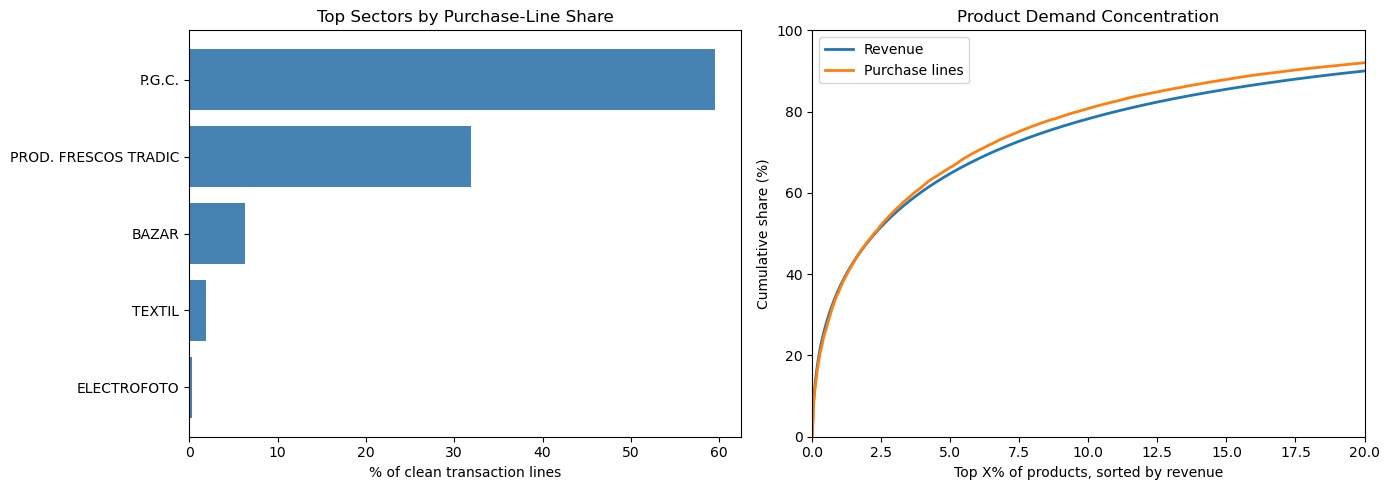

In [10]:
# 4.5.1 Product demand and concentration
from IPython.display import display
from src.config import ROOT

# Product EDA always reads the full production clean dataset, even in dev mode.
PROD_PROCESSED = ROOT / "data" / "processed"
product_lf = pl.scan_parquet(PROD_PROCESSED / "df_combined.parquet")
PRODUCT_DEMAND_CACHE = PROD_PROCESSED / "product_eda_demand.parquet"

if PRODUCT_DEMAND_CACHE.exists():
    product_demand = pl.read_parquet(PRODUCT_DEMAND_CACHE)
    print(f"Loaded product demand cache: {len(product_demand):,} products")
else:
    product_demand = (
        product_lf
        .group_by(["idarticu", "desc_larga_articulo", "desc_sector"])
        .agg([
            pl.len().alias("purchase_lines"),
            pl.col("unidades").sum().alias("units"),
            pl.col("importe").sum().alias("revenue"),
            pl.col("cliente").approx_n_unique().alias("approx_customers"),
            pl.col("ticket").approx_n_unique().alias("approx_baskets"),
        ])
        .sort("purchase_lines", descending=True)
        .collect(engine="streaming")
    )
    product_demand.write_parquet(PRODUCT_DEMAND_CACHE, compression="zstd")
    print(f"Computed and cached product demand: {len(product_demand):,} products")

sector_demand = (
    product_demand
    .group_by("desc_sector")
    .agg([
        pl.len().alias("n_products"),
        pl.col("purchase_lines").sum().alias("purchase_lines"),
        pl.col("units").sum().alias("units"),
        pl.col("revenue").sum().alias("revenue"),
        pl.col("approx_customers").sum().alias("summed_product_customer_reach"),
    ])
    .with_columns([
        (pl.col("purchase_lines") / pl.col("purchase_lines").sum() * 100).alias("line_share_pct"),
        (pl.col("revenue") / pl.col("revenue").sum() * 100).alias("revenue_share_pct"),
    ])
    .sort("purchase_lines", descending=True)
)

total_revenue = float(product_demand["revenue"].sum())
total_lines = int(product_demand["purchase_lines"].sum())
n_product_skus = len(product_demand)

product_concentration = (
    product_demand
    .sort("revenue", descending=True)
    .with_row_index("rank", offset=1)
    .with_columns([
        (pl.col("rank") / n_product_skus * 100).alias("product_pct"),
        (pl.col("revenue").cum_sum() / total_revenue * 100).alias("cum_revenue_pct"),
        (pl.col("purchase_lines").cum_sum() / total_lines * 100).alias("cum_line_pct"),
    ])
)

concentration_rows = []
for pct in [1, 5, 10, 20]:
    row = product_concentration.filter(pl.col("product_pct") <= pct)
    concentration_rows.append({
        "top_product_pct": f"Top {pct}%",
        "cum_revenue_pct": float(row["cum_revenue_pct"].max()),
        "cum_line_pct": float(row["cum_line_pct"].max()),
    })
product_concentration_summary = pd.DataFrame(concentration_rows)

print("Top products by purchase lines:")
display(
    product_demand
    .select(["idarticu", "desc_larga_articulo", "desc_sector", "purchase_lines", "units", "revenue", "approx_customers"])
    .head(15)
    .to_pandas()
)

print("Product demand concentration:")
display(product_concentration_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sector_pd = sector_demand.head(12).to_pandas()
axes[0].barh(sector_pd["desc_sector"], sector_pd["line_share_pct"], color="steelblue")
axes[0].invert_yaxis()
axes[0].set_title("Top Sectors by Purchase-Line Share")
axes[0].set_xlabel("% of clean transaction lines")

conc_pd = product_concentration.select(["product_pct", "cum_revenue_pct", "cum_line_pct"]).to_pandas()
axes[1].plot(conc_pd["product_pct"], conc_pd["cum_revenue_pct"], label="Revenue", lw=2)
axes[1].plot(conc_pd["product_pct"], conc_pd["cum_line_pct"], label="Purchase lines", lw=2)
axes[1].set_xlim(0, 20)
axes[1].set_ylim(0, 100)
axes[1].set_title("Product Demand Concentration")
axes[1].set_xlabel("Top X% of products, sorted by revenue")
axes[1].set_ylabel("Cumulative share (%)")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUTS / "eda_product_demand_concentration.png", dpi=120)
plt.show()

<a id="25-basket-structure-and-co-purchase-patterns"></a>
## 2.5 Basket Structure and Co-Purchase Patterns

Check whether products appear together in recurring combinations. This directly motivates Item2Vec in Notebook 03, where baskets become product-context sentences.

In [11]:
# 4.5.2 Basket composition and high-lift product pairs
from collections import Counter
from itertools import combinations

TOP_N_PAIR_PRODUCTS = 250
PAIR_BASKET_SAMPLE = 500_000
MIN_PAIR_BASKETS = 75
PAIR_LIFT_CACHE = PROD_PROCESSED / "product_eda_pair_lift_top250.parquet"

top_pair_ids = (
    product_demand
    .sort("purchase_lines", descending=True)
    .head(TOP_N_PAIR_PRODUCTS)["idarticu"]
    .to_list()
)

if PAIR_LIFT_CACHE.exists():
    pair_lift = pl.read_parquet(PAIR_LIFT_CACHE)
    print(f"Loaded pair-lift cache: {len(pair_lift):,} product pairs")
else:
    basket_products = (
        product_lf
        .filter(pl.col("idarticu").is_in(top_pair_ids))
        .select(["ticket", "idarticu"])
        .unique()
        .group_by("ticket")
        .agg(pl.col("idarticu").sort().alias("products"))
        .filter(pl.col("products").list.len() >= 2)
        .collect(engine="streaming")
    )

    if len(basket_products) > PAIR_BASKET_SAMPLE:
        basket_products = basket_products.sample(n=PAIR_BASKET_SAMPLE, seed=42)

    item_counter = Counter()
    pair_counter = Counter()
    for products in basket_products["products"].to_list():
        unique_products = sorted(set(products))
        item_counter.update(unique_products)
        pair_counter.update(combinations(unique_products, 2))

    n_baskets_for_pairs = len(basket_products)
    product_lookup = {
        row["idarticu"]: (row["desc_larga_articulo"], row["desc_sector"])
        for row in product_demand
        .select(["idarticu", "desc_larga_articulo", "desc_sector"])
        .iter_rows(named=True)
    }

    rows = []
    for (prod_a, prod_b), pair_count in pair_counter.items():
        if pair_count < MIN_PAIR_BASKETS:
            continue
        support_a = item_counter[prod_a] / n_baskets_for_pairs
        support_b = item_counter[prod_b] / n_baskets_for_pairs
        pair_support = pair_count / n_baskets_for_pairs
        lift = pair_support / (support_a * support_b) if support_a and support_b else None
        desc_a, sector_a = product_lookup.get(prod_a, (str(prod_a), None))
        desc_b, sector_b = product_lookup.get(prod_b, (str(prod_b), None))
        rows.append({
            "idarticu_a": prod_a,
            "product_a": desc_a,
            "sector_a": sector_a,
            "idarticu_b": prod_b,
            "product_b": desc_b,
            "sector_b": sector_b,
            "pair_baskets": pair_count,
            "lift": lift,
        })

    pair_lift = pl.DataFrame(rows).sort(["lift", "pair_baskets"], descending=[True, True])
    pair_lift.write_parquet(PAIR_LIFT_CACHE, compression="zstd")
    print(f"Computed pair lift from {n_baskets_for_pairs:,} baskets; cached {len(pair_lift):,} pairs")

print("High-lift product pairs among frequent SKUs:")
display(
    pair_lift
    .select(["product_a", "product_b", "sector_a", "sector_b", "pair_baskets", "lift"])
    .with_columns(pl.col("lift").round(2))
    .head(20)
    .to_pandas()
)

Computed pair lift from 500,000 baskets; cached 17,788 pairs
High-lift product pairs among frequent SKUs:


,product_a,product_b,sector_a,sector_b,pair_baskets,lift
0,MACARRONES CARREFOUR 1 KG,ESPAGUETTIS CARREFOUR 1 KG,P.G.C.,P.G.C.,1047,27.19
1,DONUTS FONDANT 4 UNDS 204 G,DONUT GLACE 4 UD 208 G RR,P.G.C.,P.G.C.,1187,20.00
2,OFERTA CARNICERIA,OFERTA REFRIGERADO,PROD. FRESCOS TRADIC,P.G.C.,923,17.76
3,OFERTA CARNICERIA,PROMOCION FRUTA,PROD. FRESCOS TRADIC,PROD. FRESCOS TRADIC,736,16.86
4,PIMIENTO ITALIANO (MERCADO),PIMIENTO ROJO (MERCADO),PROD. FRESCOS TRADIC,PROD. FRESCOS TRADIC,1068,16.47
5,OFERTA REFRIGERADO,PROMOCION FRUTA,P.G.C.,PROD. FRESCOS TRADIC,656,14.44
6,MELON PIEL SAPO,SANDIA RAYADA,PROD. FRESCOS TRADIC,PROD. FRESCOS TRADIC,430,13.97
7,"PERA CONFERENCIA SIMPL 1,5K","MANZANA GOLDEN SIIMPL 1,5K",PROD. FRESCOS TRADIC,PROD. FRESCOS TRADIC,691,13.02
8,ARROZ CATEGORIA PRIMERA CARREFOUR 1 KG,MACARRONES CARREFOUR 1 KG,P.G.C.,P.G.C.,649,11.64
9,ARROZ LARGO CARREFOUR 1 KG,ESPAGUETTIS CARREFOUR 1 KG,P.G.C.,P.G.C.,769,11.47


<a id="26-product-timing-and-shopping-context"></a>
## 2.6 Product Timing and Shopping Context

Evaluate weekday and hour patterns to see whether product behaviour reflects shopping missions, routines, or time-specific demand.

Computed and cached temporal lift tables


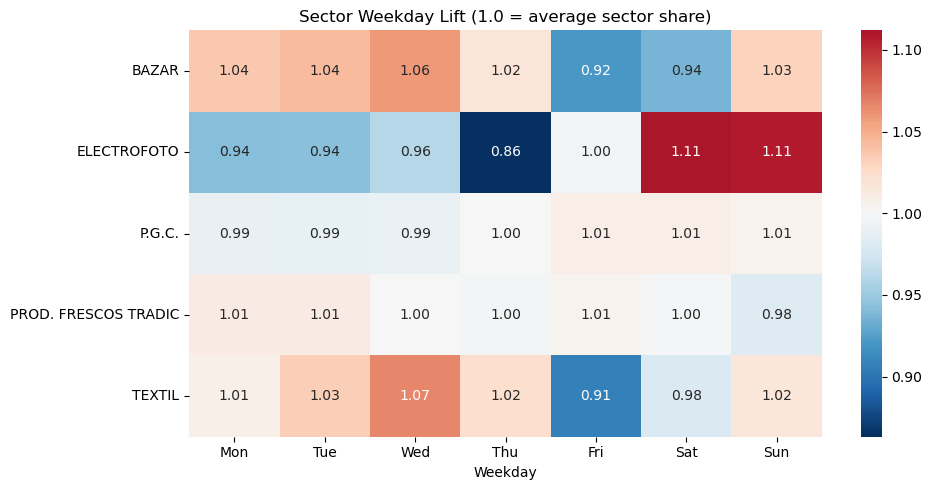

Specific products with the strongest hour-of-day lift:


,hour,desc_larga_articulo,desc_sector,lines,lift
0,3,BOLSA 40X50CM 100% PLASTICO RECICLADO CARREFOUR,BAZAR,216,9.33
1,4,BOLSA 40X50CM 100% PLASTICO RECICLADO CARREFOUR,BAZAR,130,8.97
2,5,BOLSA 40X50CM 100% PLASTICO RECICLADO CARREFOUR,BAZAR,105,7.99
3,1,BOLSA 40X50CM 100% PLASTICO RECICLADO CARREFOUR,BAZAR,526,7.92
4,0,BOLSA 40X50CM 100% PLASTICO RECICLADO CARREFOUR,BAZAR,919,6.89
5,2,BOLSA 40X50CM 100% PLASTICO RECICLADO CARREFOUR,BAZAR,226,6.72
6,6,BOLSA 40X50CM 100% PLASTICO RECICLADO CARREFOUR,BAZAR,163,5.41
7,23,BOLSA 40X50CM 100% PLASTICO RECICLADO CARREFOUR,BAZAR,1570,4.25
8,7,BOLSA 40X50CM 100% PLASTICO RECICLADO CARREFOUR,BAZAR,342,3.42
9,7,BARRAS DE PAN CARREFOUR 3 UNDS 750G,PROD. FRESCOS TRADIC,988,3.07


In [12]:
# 4.5.3 Weekday and hour patterns for sectors and top products
TEMPORAL_CACHE = PROD_PROCESSED / "product_eda_temporal_lift.parquet"
TOP_N_TEMPORAL_PRODUCTS = 100
MIN_PRODUCT_HOUR_LINES = 100
weekday_names = {1: "Mon", 2: "Tue", 3: "Wed", 4: "Thu", 5: "Fri", 6: "Sat", 7: "Sun"}

top_temporal_ids = (
    product_demand
    .sort("purchase_lines", descending=True)
    .head(TOP_N_TEMPORAL_PRODUCTS)["idarticu"]
    .to_list()
)

if TEMPORAL_CACHE.exists():
    temporal_bundle = pl.read_parquet(TEMPORAL_CACHE)
    sector_weekday_lift = temporal_bundle.filter(pl.col("analysis") == "sector_weekday")
    product_hour_lift = temporal_bundle.filter(pl.col("analysis") == "product_hour")
    print("Loaded temporal lift cache")
else:
    temporal_base = (
        product_lf
        .select(["fecha", "hora", "idarticu", "desc_larga_articulo", "desc_sector"])
        .with_columns([
            pl.col("fecha").dt.weekday().alias("weekday"),
            (pl.col("hora").cast(pl.Int32, strict=False) // 100).alias("hour"),
        ])
    )

    sector_weekday_counts = (
        temporal_base
        .drop_nulls(["desc_sector", "weekday"])
        .group_by(["desc_sector", "weekday"])
        .agg(pl.len().alias("lines"))
        .collect(engine="streaming")
    )
    total_sector_weekday_lines = int(sector_weekday_counts["lines"].sum())
    sector_totals = sector_weekday_counts.group_by("desc_sector").agg(pl.col("lines").sum().alias("sector_lines"))
    weekday_totals = sector_weekday_counts.group_by("weekday").agg(pl.col("lines").sum().alias("weekday_lines"))
    sector_weekday_lift = (
        sector_weekday_counts
        .join(sector_totals, on="desc_sector")
        .join(weekday_totals, on="weekday")
        .with_columns(
            ((pl.col("lines") / pl.col("weekday_lines")) /
             (pl.col("sector_lines") / total_sector_weekday_lines)).alias("lift")
        )
        .with_columns([
            pl.lit("sector_weekday").alias("analysis"),
            pl.col("weekday").cast(pl.Int64),
            pl.lit(None, dtype=pl.Int64).alias("idarticu"),
            pl.lit(None, dtype=pl.Utf8).alias("desc_larga_articulo"),
            pl.lit(None, dtype=pl.Int64).alias("hour"),
        ])
        .select(["analysis", "desc_sector", "weekday", "hour", "idarticu", "desc_larga_articulo", "lines", "lift"])
    )

    product_hour_counts = (
        temporal_base
        .filter(pl.col("idarticu").is_in(top_temporal_ids))
        .drop_nulls(["hour"])
        .group_by(["idarticu", "desc_larga_articulo", "desc_sector", "hour"])
        .agg(pl.len().alias("lines"))
        .collect(engine="streaming")
    )
    total_product_hour_lines = int(product_hour_counts["lines"].sum())
    product_totals = product_hour_counts.group_by("idarticu").agg(pl.col("lines").sum().alias("product_lines"))
    hour_totals = product_hour_counts.group_by("hour").agg(pl.col("lines").sum().alias("hour_lines"))
    product_hour_lift = (
        product_hour_counts
        .join(product_totals, on="idarticu")
        .join(hour_totals, on="hour")
        .with_columns(
            ((pl.col("lines") / pl.col("hour_lines")) /
             (pl.col("product_lines") / total_product_hour_lines)).alias("lift")
        )
        .filter(pl.col("lines") >= MIN_PRODUCT_HOUR_LINES)
        .with_columns([
            pl.lit("product_hour").alias("analysis"),
            pl.lit(None, dtype=pl.Int64).alias("weekday"),
            pl.col("hour").cast(pl.Int64),
            pl.col("idarticu").cast(pl.Int64),
        ])
        .select(["analysis", "desc_sector", "weekday", "hour", "idarticu", "desc_larga_articulo", "lines", "lift"])
    )

    temporal_bundle = pl.concat([sector_weekday_lift, product_hour_lift], how="vertical")
    temporal_bundle.write_parquet(TEMPORAL_CACHE, compression="zstd")
    print("Computed and cached temporal lift tables")

sector_weekday_pd = sector_weekday_lift.to_pandas()
sector_weekday_pd["weekday_name"] = sector_weekday_pd["weekday"].map(weekday_names)

heatmap_source = sector_weekday_pd.copy()
top_heatmap_sectors = (
    heatmap_source.groupby("desc_sector")["lines"].sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)
heatmap_data = (
    heatmap_source[heatmap_source["desc_sector"].isin(top_heatmap_sectors)]
    .pivot_table(index="desc_sector", columns="weekday_name", values="lift", aggfunc="mean")
    .reindex(columns=["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(heatmap_data, center=1.0, cmap="RdBu_r", annot=True, fmt=".2f", ax=ax)
ax.set_title("Sector Weekday Lift (1.0 = average sector share)")
ax.set_xlabel("Weekday")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(OUTPUTS / "eda_sector_weekday_lift.png", dpi=120)
plt.show()

print("Specific products with the strongest hour-of-day lift:")
display(
    product_hour_lift
    .sort(["lift", "lines"], descending=[True, True])
    .select(["hour", "desc_larga_articulo", "desc_sector", "lines", "lift"])
    .with_columns(pl.col("lift").round(2))
    .head(20)
    .to_pandas()
)

<a id="27-customer-product-recurrence"></a>
## 2.7 Customer-Product Recurrence

Identify repeated customer-product relationships that indicate replenishment habits, product loyalty, and stable preferences. These patterns justify frequency and recency weighting in customer vectors.

In [13]:
# 2.7 Repeating customer-product relationships
import polars as pl
from IPython.display import display
from src.config import ROOT

# Kernel-safe recurrence EDA:
# A full customer x product groupby over the 10GB processed transaction table can
# exceed notebook memory. Use the much smaller dev subset when available; if it is
# missing, read only a bounded prefix of the full table so the kernel stays alive.
PROD_PROCESSED = ROOT / "data" / "processed"
DEV_COMBINED = ROOT / "data" / "dev" / "df_combined.parquet"
FULL_COMBINED = PROD_PROCESSED / "df_combined.parquet"

USE_DEV_SUBSET = DEV_COMBINED.exists()
SOURCE_COMBINED = DEV_COMBINED if USE_DEV_SUBSET else FULL_COMBINED
SOURCE_LABEL = "dev subset" if USE_DEV_SUBSET else "bounded full-file prefix"

REPEAT_PAIR_CACHE = PROD_PROCESSED / (
    "product_eda_customer_product_repeats_dev.parquet"
    if USE_DEV_SUBSET
    else "product_eda_customer_product_repeats_full_prefix.parquet"
)
PRODUCT_DEMAND_CACHE = PROD_PROCESSED / "product_eda_demand.parquet"
MIN_REPEAT_LINES = 3
MAX_FULL_FALLBACK_ROWS = 1_000_000
MAX_REPEAT_PAIRS_TO_KEEP = 50_000
MIN_REPEAT_CUSTOMERS_FOR_RATE = 10

if REPEAT_PAIR_CACHE.exists():
    repeat_pairs = pl.read_parquet(REPEAT_PAIR_CACHE)
    print(f"Loaded repeat customer-product cache from {SOURCE_LABEL}: {len(repeat_pairs):,} repeated pairs")
else:
    recurrence_lf = (
        pl.scan_parquet(SOURCE_COMBINED)
        .select(["cliente", "idarticu", "desc_larga_articulo", "desc_sector", "unidades", "importe", "ticket", "fecha"])
    )
    if not USE_DEV_SUBSET:
        recurrence_lf = recurrence_lf.head(MAX_FULL_FALLBACK_ROWS)

    print(f"Reading recurrence input from {SOURCE_LABEL}: {SOURCE_COMBINED}")
    if not USE_DEV_SUBSET:
        print(f"Fallback is capped at {MAX_FULL_FALLBACK_ROWS:,} transaction lines.")

    recurrence_rows = recurrence_lf.collect(engine="streaming")
    print(f"Loaded {len(recurrence_rows):,} transaction lines for recurrence EDA")

    repeat_pairs = (
        recurrence_rows
        .group_by(["cliente", "idarticu", "desc_larga_articulo", "desc_sector"])
        .agg([
            pl.len().alias("purchase_lines"),
            pl.col("unidades").sum().alias("units"),
            pl.col("importe").sum().alias("revenue"),
            pl.col("ticket").approx_n_unique().alias("approx_baskets"),
            pl.col("fecha").min().alias("first_date"),
            pl.col("fecha").max().alias("last_date"),
            pl.col("fecha").approx_n_unique().alias("purchase_days"),
        ])
        .filter(pl.col("purchase_lines") >= MIN_REPEAT_LINES)
        .with_columns((pl.col("last_date") - pl.col("first_date")).dt.total_days().alias("span_days"))
        .sort(["purchase_lines", "revenue"], descending=[True, True])
        .head(MAX_REPEAT_PAIRS_TO_KEEP)
    )
    repeat_pairs.write_parquet(REPEAT_PAIR_CACHE, compression="zstd")
    print(f"Computed and cached repeat customer-product pairs: {len(repeat_pairs):,}")

# Optional product-level denominator from Section 2.4.1, used only for context.
if "product_demand" not in globals() and PRODUCT_DEMAND_CACHE.exists():
    product_demand = pl.read_parquet(PRODUCT_DEMAND_CACHE)

repeat_product_summary = (
    repeat_pairs
    .group_by(["idarticu", "desc_larga_articulo", "desc_sector"])
    .agg([
        pl.len().alias("repeat_customers_in_sample"),
        pl.col("purchase_lines").mean().alias("avg_lines_per_repeat_customer"),
        pl.col("purchase_lines").max().alias("max_customer_lines"),
        pl.col("revenue").sum().alias("repeat_pair_revenue"),
    ])
    .filter(pl.col("repeat_customers_in_sample") >= MIN_REPEAT_CUSTOMERS_FOR_RATE)
    .sort(["repeat_customers_in_sample", "avg_lines_per_repeat_customer"], descending=[True, True])
)

if "product_demand" in globals():
    repeat_product_summary = repeat_product_summary.join(
        product_demand.select(["idarticu", "approx_customers"]),
        on="idarticu",
        how="left",
    )
else:
    repeat_product_summary = repeat_product_summary.with_columns(
        pl.lit(None, dtype=pl.Int64).alias("approx_customers")
    )

print("Most recurring customer-product pairs in the EDA sample:")
display(
    repeat_pairs
    .select(["cliente", "idarticu", "desc_larga_articulo", "desc_sector", "purchase_lines", "approx_baskets", "purchase_days", "span_days", "revenue"])
    .head(20)
    .to_pandas()
)

print(
    "Products with most repeat customers in the EDA sample "
    f"(>= {MIN_REPEAT_CUSTOMERS_FOR_RATE} repeat customers):"
)
display(
    repeat_product_summary
    .select([
        "idarticu",
        "desc_larga_articulo",
        "desc_sector",
        "repeat_customers_in_sample",
        "approx_customers",
        "avg_lines_per_repeat_customer",
        "max_customer_lines",
        "repeat_pair_revenue",
    ])
    .with_columns(pl.col("avg_lines_per_repeat_customer").round(2))
    .head(20)
    .to_pandas()
)

print(
    "Note: this is a bounded recurrence readout for EDA stability. "
    "The full recurrence signal is captured later by the sparse interaction-weight "
    "pipeline used to build customer vectors."
)


Reading recurrence input from bounded full-file prefix: C:\Users\sebog\proyectos\carrefour_capstone\data\processed\df_combined.parquet
Fallback is capped at 1,000,000 transaction lines.
Loaded 1,000,000 transaction lines for recurrence EDA
Computed and cached repeat customer-product pairs: 237
Most recurring customer-product pairs in the EDA sample:


,cliente,idarticu,desc_larga_articulo,desc_sector,purchase_lines,approx_baskets,purchase_days,span_days,revenue
0,153b062649554ed7d00889bff426551e88b1174c256d47...,115818,CERVEZA ESPECIAL CARREFOUR LATA 33CL,P.G.C.,5,5,5,133,14.84
1,d703e2181d9bfc1fbe8c96cbb67ccf2ed8f9fc22077d1c...,632052,BOLSA 48X60CM 100% PLASTICO RECICLADO CARREFOUR,BAZAR,5,5,5,117,0.58
2,285ab0bf89a93aadea909fa5dca3e14f5d5066f60ec0f3...,179543,CARNICERIA FRQ,PROD. FRESCOS TRADIC,4,4,4,114,56.40
3,804f537c66e6b6550e5ec63e46a9fa92c83168092f5e3d...,123190,MONSTER GREEN LATA 50CL,P.G.C.,4,4,4,133,16.49
4,e71cb7a09474eb43d0aeb1f7a99317b796ad20c83bb935...,26481,CERVEZA VOLL DAMM LATA 33 CL,P.G.C.,4,4,4,122,9.87
5,26b3d2530c972906da0d32ecbeb0bd454d071fa3b58503...,151,CERVEZA MAHOU CLASICA LATA 33 CL,P.G.C.,4,4,4,110,8.72
6,7b392ca67741ff2f2f1c9da3c9f0ed116b10de0a4e2533...,20842,GASEOSA LA CASERA PET 50CL,P.G.C.,4,4,4,46,4.68
7,660bcc18bc80d7c7cc4437b3ef7cecde8c3f4ab264e330...,668138,BARRAS DE PAN CARREFOUR 3 UNDS 750G,PROD. FRESCOS TRADIC,4,4,4,144,3.96
8,8ef81465f4afe0ad4caa6eebc5485dd02255828501339f...,216537,BARRA DE PAN CARREFOUR 250G,PROD. FRESCOS TRADIC,4,4,4,93,3.39
9,e36624a34d91016cd5a2b4dcd4714964ef0ab5e4817042...,126886,BARRA DE PISTOLA CARREFOUR 2 UNIDADES 500G,PROD. FRESCOS TRADIC,4,4,4,116,3.20


Products with most repeat customers in the EDA sample (>= 10 repeat customers):


,idarticu,desc_larga_articulo,desc_sector,repeat_customers_in_sample,approx_customers,avg_lines_per_repeat_customer,max_customer_lines,repeat_pair_revenue
0,632052,BOLSA 48X60CM 100% PLASTICO RECICLADO CARREFOUR,BAZAR,60,802903,3.10,5,29.27
1,216537,BARRA DE PAN CARREFOUR 250G,PROD. FRESCOS TRADIC,22,354784,3.09,4,34.92


Note: this is a bounded recurrence readout for EDA stability. The full recurrence signal is captured later by the sparse interaction-weight pipeline used to build customer vectors.


<a id="28-customer-behavioural-spread"></a>
## 2.8 Customer Behavioural Spread

After establishing product-level structure, measure whether customers differ enough in visits, spend, basket size, promotion rate, and product variety to support clustering.

In [ ]:
# ── 4.1 Per-customer KPI distributions (all 1.48M customers) ──────────────────
# KPIs are always computed from the prod dataset and cached in data/processed/.
from src.config import ROOT

PROD_PROCESSED = ROOT / "data" / "processed"
_cache_path = PROD_PROCESSED / "customer_kpis.parquet"

if _cache_path.exists():
    cust_stats = pd.read_parquet(_cache_path)
    print(f"Loaded customer KPIs from cache ({len(cust_stats):,} rows)")
else:
    clean_lf = pl.scan_parquet(PROD_PROCESSED / "df_combined.parquet")

    # Quantise EUR → integer eurocents before streaming aggregation.
    # Integer addition is associative; float addition is not, so streaming
    # chunk-merge order (which varies by RAM/OS) produces different totals
    # on different machines — breaking strata reproducibility.
    _EUR_SCALE = 100

    basket_lf = (
        clean_lf
        .with_columns(
            (pl.col("importe") * _EUR_SCALE).round(0).cast(pl.Int64).alias("importe_cents")
        )
        .group_by(["cliente", "ticket"])
        .agg([
            pl.len().alias("n_items"),
            pl.col("importe_cents").sum().alias("total_spend_cents"),  # Int64 — associative
            (pl.col("idpromoc") == "Promo").sum().cast(pl.Float64).alias("promo_items"),
        ])
        .with_columns((pl.col("promo_items") / pl.col("n_items")).alias("promo_rate"))
    )

    cust_lf = (
        basket_lf.group_by("cliente").agg([
            pl.len().alias("visit_count"),
            pl.col("total_spend_cents").sum().alias("total_spend_6m_cents"),  # Int64 — associative
            pl.col("total_spend_cents").mean().alias("avg_basket_cents"),      # sum_int/count — deterministic
            pl.col("promo_rate").mean().alias("avg_promo_rate"),
        ])
        .with_columns([
            (pl.col("total_spend_6m_cents").cast(pl.Float64) / _EUR_SCALE).alias("total_spend_6m"),
            (pl.col("avg_basket_cents") / _EUR_SCALE).alias("avg_basket_size"),
        ])
        .drop(["total_spend_6m_cents", "avg_basket_cents"])
    )

    diversity_lf = clean_lf.group_by("cliente").agg(
        pl.col("idarticu").n_unique().alias("unique_products")
    )

    # Two sequential streaming collects — each processes 190M rows in micro-batches,
    # keeping peak RAM proportional to batch size rather than full dataset size.
    cust_df      = cust_lf.collect(engine="streaming").to_pandas()
    diversity_df = diversity_lf.collect(engine="streaming").to_pandas()
    cust_stats = (
        cust_df.merge(diversity_df, on="cliente")
        .sort_values("cliente")
        .reset_index(drop=True)
    )

    cust_stats.to_parquet(_cache_path, index=False)
    print(f"Computed and cached customer KPIs → {_cache_path}")

print(f"Customer KPI summary (n={len(cust_stats):,}):")
print(cust_stats[["visit_count","avg_basket_size","total_spend_6m","avg_promo_rate","unique_products"]]
      .describe().round(2).to_string())

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
cust_stats["visit_count"].clip(upper=50).plot.hist(
    bins=40, ax=axes[0,0], color="steelblue", edgecolor="white",
    title="Visits per Customer (6 months)")
axes[0,0].set_xlabel("# visits")
cust_stats["avg_basket_size"].clip(upper=100).plot.hist(
    bins=40, ax=axes[0,1], color="coral", edgecolor="white",
    title="Avg Basket Size € (clipped at 100)")
axes[0,1].set_xlabel("€")
cust_stats["total_spend_6m"].clip(upper=2000).plot.hist(
    bins=50, ax=axes[0,2], color="mediumseagreen", edgecolor="white",
    title="Total 6-Month Spend € (clipped at 2,000)")
axes[0,2].set_xlabel("€")
cust_stats["avg_promo_rate"].plot.hist(
    bins=30, ax=axes[1,0], color="mediumpurple", edgecolor="white",
    title="Avg Promotional Purchase Rate")
axes[1,0].set_xlabel("Promo rate (0=never, 1=always promo)")
cust_stats["unique_products"].clip(upper=200).plot.hist(
    bins=40, ax=axes[1,1], color="darkorange", edgecolor="white",
    title="Unique Products per Customer (clipped at 200)")
axes[1,1].set_xlabel("# unique products")
s = cust_stats.sample(min(5000, len(cust_stats)), random_state=42)
sc = axes[1,2].scatter(s["visit_count"].clip(upper=50),
                        s["avg_basket_size"].clip(upper=150),
                        c=s["avg_promo_rate"], cmap="RdYlGn_r",
                        s=4, alpha=0.4)
plt.colorbar(sc, ax=axes[1,2], label="Promo rate")
axes[1,2].set_xlabel("Visit count"); axes[1,2].set_ylabel("Avg basket €")
axes[1,2].set_title("Visits vs Basket (colour = promo rate)")
plt.suptitle("Customer Behavioural KPI Distributions — All 1.48M Customers",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUTS / "eda_customer_kpis.png", dpi=120)
plt.show()

<a id="29-promo-store-and-revenue-context"></a>
## 2.9 Promo, Store and Revenue Context

Assess commercial and operational context. Promo sensitivity, store behaviour, and revenue concentration can help explain final tribes, but they should not overpower product-led segmentation.

### 2.9.1 Promotional Sensitivity Analysis

The `idpromoc` field separates brand-loyal purchase behaviour from promo-driven behaviour. This is useful both as a profiling dimension and as a possible confounder for product-led tribes.

Computed and cached promo sector rates: 5 sectors


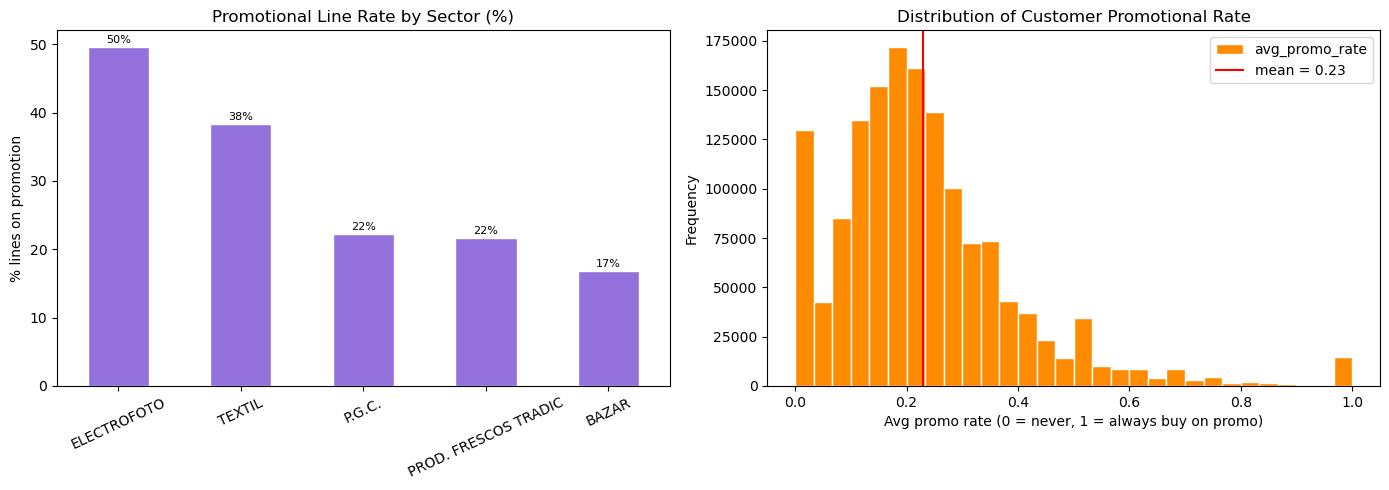

Overall promo rate in dataset    : 22.1%
Customers with 0% promo          : 8.1%
Customers with >50% promo        : 5.3%


In [15]:
# 2.9.1 Promotional sensitivity: sector and customer level
# Key differentiating axis: promo surfers vs brand loyalists.
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

from src.config import ROOT, OUTPUTS

PROD_PROCESSED = ROOT / "data" / "processed"
PROMO_SECTOR_CACHE = PROD_PROCESSED / "eda_promo_sector.parquet"
CUSTOMER_KPI_CACHE = PROD_PROCESSED / "customer_kpis.parquet"
COMBINED_PATH = PROD_PROCESSED / "df_combined.parquet"

if "cust_stats" not in globals():
    if not CUSTOMER_KPI_CACHE.exists():
        raise RuntimeError("customer_kpis.parquet is missing. Run Section 2.8 first.")
    cust_stats = pd.read_parquet(CUSTOMER_KPI_CACHE)
    print(f"Loaded customer KPIs from cache ({len(cust_stats):,} rows)")

if PROMO_SECTOR_CACHE.exists():
    promo_sector_pl = pl.read_parquet(PROMO_SECTOR_CACHE)
    print(f"Loaded promo sector cache: {len(promo_sector_pl):,} sectors")
else:
    if "df_combined" not in globals():
        if not COMBINED_PATH.exists():
            raise RuntimeError("df_combined.parquet is missing. Run Section 2.3 first.")
        df_combined = pl.scan_parquet(COMBINED_PATH)

    promo_sector_pl = (
        df_combined
        .drop_nulls("desc_sector")
        .group_by("desc_sector")
        .agg([
            pl.len().alias("total"),
            (pl.col("idpromoc") == "Promo").sum().alias("promo"),
        ])
        .with_columns((pl.col("promo").cast(pl.Float64) / pl.col("total") * 100).alias("promo_rate_pct"))
        .sort("promo_rate_pct", descending=True)
        .collect(engine="streaming")
    )
    promo_sector_pl.write_parquet(PROMO_SECTOR_CACHE, compression="zstd")
    print(f"Computed and cached promo sector rates: {len(promo_sector_pl):,} sectors")

promo_sector = promo_sector_pl.to_pandas().set_index("desc_sector")
overall_promo_rate = promo_sector["promo"].sum() / promo_sector["total"].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
promo_sector["promo_rate_pct"].plot.bar(
    ax=axes[0], color="mediumpurple", edgecolor="white",
    title="Promotional Line Rate by Sector (%)",
)
axes[0].set_xlabel("")
axes[0].set_ylabel("% lines on promotion")
axes[0].tick_params(axis="x", rotation=25)
for bar in axes[0].patches:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{bar.get_height():.0f}%",
        ha="center",
        va="bottom",
        fontsize=8,
    )

cust_stats["avg_promo_rate"].plot.hist(
    bins=30, ax=axes[1], color="darkorange", edgecolor="white",
    title="Distribution of Customer Promotional Rate",
)
axes[1].axvline(
    cust_stats["avg_promo_rate"].mean(),
    color="red",
    lw=1.5,
    label=f"mean = {cust_stats['avg_promo_rate'].mean():.2f}",
)
axes[1].legend()
axes[1].set_xlabel("Avg promo rate (0 = never, 1 = always buy on promo)")
plt.tight_layout()
plt.savefig(OUTPUTS / "eda_promo_analysis.png", dpi=120)
plt.show()

print(f"Overall promo rate in dataset    : {overall_promo_rate*100:.1f}%")
print(f"Customers with 0% promo          : {(cust_stats['avg_promo_rate'] == 0).mean()*100:.1f}%")
print(f"Customers with >50% promo        : {(cust_stats['avg_promo_rate'] > 0.5).mean()*100:.1f}%")


### 2.9.2 Customer Revenue Concentration

A Lorenz curve of customer spend shows how unequally revenue is distributed. If a minority of customers drives a disproportionate share of revenue, segmenting and protecting those customers becomes commercially important.

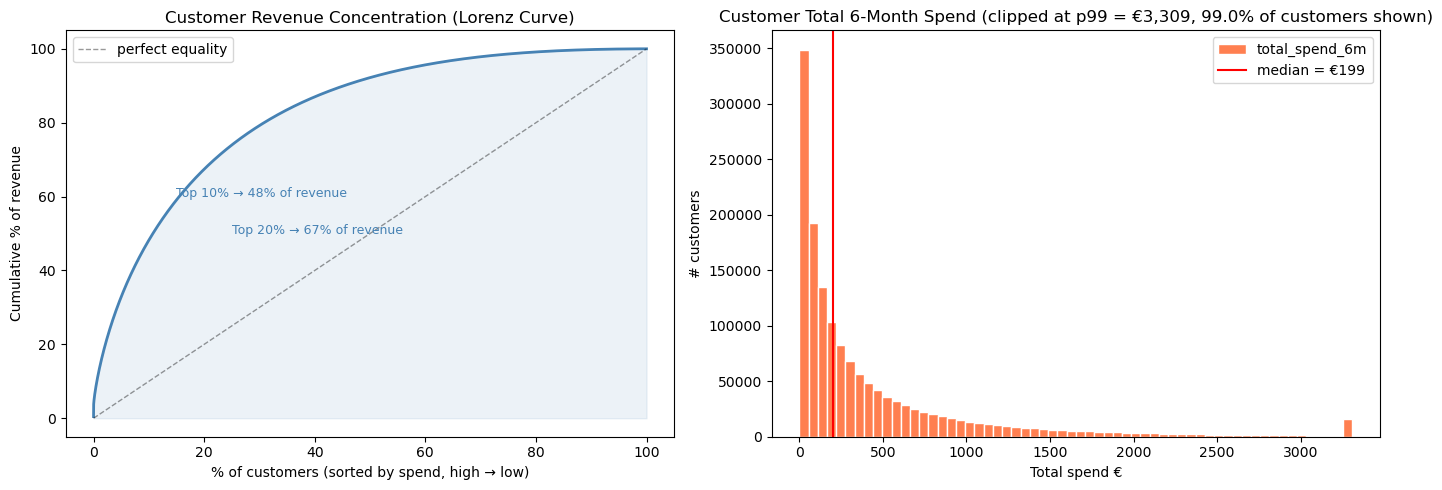

Top 10% of customers drive 48% of revenue
Top 20% of customers drive 67% of revenue
Median 6-month spend: €199
p99 spend (clip threshold): €3,309


In [16]:
# ── 6. Revenue concentration by customer (CLV preview) ───────────────────────
cust_stats_sorted = cust_stats.sort_values("total_spend_6m", ascending=False).reset_index(drop=True)
cust_stats_sorted["cumulative_rev_pct"] = (
    cust_stats_sorted["total_spend_6m"].cumsum() / cust_stats_sorted["total_spend_6m"].sum() * 100
)
cust_stats_sorted["customer_pct"] = (cust_stats_sorted.index + 1) / len(cust_stats_sorted) * 100

top10_share = cust_stats_sorted[cust_stats_sorted["customer_pct"] <= 10]["total_spend_6m"].sum() \
              / cust_stats_sorted["total_spend_6m"].sum() * 100
top20_share = cust_stats_sorted[cust_stats_sorted["customer_pct"] <= 20]["total_spend_6m"].sum() \
              / cust_stats_sorted["total_spend_6m"].sum() * 100

# clip threshold: 99th percentile — shows 99% of customers, cuts extreme outliers
_clip_p99 = cust_stats["total_spend_6m"].quantile(0.99)
_pct_shown = (cust_stats["total_spend_6m"] <= _clip_p99).mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cust_stats_sorted["customer_pct"], cust_stats_sorted["cumulative_rev_pct"],
             color="steelblue", lw=2)
axes[0].plot([0, 100], [0, 100], "k--", lw=1, alpha=0.4, label="perfect equality")
axes[0].fill_between(cust_stats_sorted["customer_pct"], cust_stats_sorted["cumulative_rev_pct"],
                     alpha=0.1, color="steelblue")
axes[0].set_xlabel("% of customers (sorted by spend, high → low)")
axes[0].set_ylabel("Cumulative % of revenue")
axes[0].set_title("Customer Revenue Concentration (Lorenz Curve)")
axes[0].text(15, 60, f"Top 10% → {top10_share:.0f}% of revenue", fontsize=9, color="steelblue")
axes[0].text(25, 50, f"Top 20% → {top20_share:.0f}% of revenue", fontsize=9, color="steelblue")
axes[0].legend()

cust_stats["total_spend_6m"].clip(upper=_clip_p99).plot.hist(
    bins=60, ax=axes[1], color="coral", edgecolor="white",
    title=f"Customer Total 6-Month Spend (clipped at p99 = €{_clip_p99:,.0f}, {_pct_shown:.1f}% of customers shown)")
axes[1].set_xlabel("Total spend €"); axes[1].set_ylabel("# customers")
axes[1].axvline(cust_stats["total_spend_6m"].median(), color="red", lw=1.5,
    label=f"median = €{cust_stats['total_spend_6m'].median():.0f}")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUTS / "eda_revenue_concentration.png", dpi=120)
plt.show()
print(f"Top 10% of customers drive {top10_share:.0f}% of revenue")
print(f"Top 20% of customers drive {top20_share:.0f}% of revenue")
print(f"Median 6-month spend: €{cust_stats['total_spend_6m'].median():.0f}")
print(f"p99 spend (clip threshold): €{_clip_p99:,.0f}")

<a id="210-segmentation-viability-assessment"></a>
## 2.10 Segmentation Viability Assessment

Turn the EDA into a go/no-go decision for Notebook 03. The goal is to confirm that product demand, co-purchase structure, recurrence, and customer behavioural spread are strong enough for organic tribes.

In [17]:
# 2.10 Product EDA implications for the segmentation pipeline
import pandas as pd
import polars as pl

from src.config import ROOT

PROD_PROCESSED = ROOT / "data" / "processed"
PRODUCT_DEMAND_CACHE = PROD_PROCESSED / "product_eda_demand.parquet"
PAIR_LIFT_CACHE = PROD_PROCESSED / "product_eda_pair_lift_top250.parquet"
REPEAT_PAIR_CACHE = PROD_PROCESSED / "product_eda_customer_product_repeats_dev.parquet"
MIN_REPEAT_LINES = globals().get("MIN_REPEAT_LINES", 3)
MIN_REPEAT_CUSTOMERS_FOR_RATE = globals().get("MIN_REPEAT_CUSTOMERS_FOR_RATE", 10)

if "product_demand" not in globals():
    if not PRODUCT_DEMAND_CACHE.exists():
        raise RuntimeError("product_eda_demand.parquet is missing. Run Section 2.4.1 first.")
    product_demand = pl.read_parquet(PRODUCT_DEMAND_CACHE)

if "product_concentration_summary" not in globals():
    total_revenue = float(product_demand["revenue"].sum())
    total_lines = int(product_demand["purchase_lines"].sum())
    n_products = len(product_demand)
    product_concentration = (
        product_demand
        .sort("revenue", descending=True)
        .with_row_index("rank", offset=1)
        .with_columns([
            (pl.col("rank") / n_products * 100).alias("product_pct"),
            (pl.col("revenue").cum_sum() / total_revenue * 100).alias("cum_revenue_pct"),
            (pl.col("purchase_lines").cum_sum() / total_lines * 100).alias("cum_line_pct"),
        ])
    )
    concentration_rows = []
    for pct in [1, 5, 10, 20]:
        row = product_concentration.filter(pl.col("product_pct") <= pct)
        concentration_rows.append({
            "top_product_pct": f"Top {pct}%",
            "cum_revenue_pct": float(row["cum_revenue_pct"].max()),
            "cum_line_pct": float(row["cum_line_pct"].max()),
        })
    product_concentration_summary = pd.DataFrame(concentration_rows)
else:
    n_products = globals().get("n_products", len(product_demand))

if "pair_lift" not in globals():
    pair_lift = pl.read_parquet(PAIR_LIFT_CACHE) if PAIR_LIFT_CACHE.exists() else pl.DataFrame()

if "repeat_pairs" not in globals():
    repeat_pairs = pl.read_parquet(REPEAT_PAIR_CACHE) if REPEAT_PAIR_CACHE.exists() else pl.DataFrame()

if "repeat_product_summary" not in globals():
    if len(repeat_pairs) > 0:
        repeat_product_summary = (
            repeat_pairs
            .group_by(["idarticu", "desc_larga_articulo", "desc_sector"])
            .agg([
                pl.len().alias("repeat_customers_in_sample"),
                pl.col("purchase_lines").mean().alias("avg_lines_per_repeat_customer"),
                pl.col("purchase_lines").max().alias("max_customer_lines"),
                pl.col("revenue").sum().alias("repeat_pair_revenue"),
            ])
            .filter(pl.col("repeat_customers_in_sample") >= MIN_REPEAT_CUSTOMERS_FOR_RATE)
            .sort(["repeat_customers_in_sample", "avg_lines_per_repeat_customer"], descending=[True, True])
        )
    else:
        repeat_product_summary = pl.DataFrame()

print("=" * 72)
print("  PRODUCT EDA IMPLICATIONS FOR ORGANIC TRIBES")
print("=" * 72)

for row in product_concentration_summary.itertuples(index=False):
    print(f"{row.top_product_pct:<8} of SKUs account for {row.cum_revenue_pct:5.1f}% of revenue and {row.cum_line_pct:5.1f}% of lines")

print()
print(f"High-lift product pairs retained          : {len(pair_lift):,}")
if len(pair_lift) > 0:
    top_pair = pair_lift.row(0, named=True)
    print("Strongest product-pair lift               : "
          f"{top_pair['product_a'][:30]} + {top_pair['product_b'][:30]} "
          f"({top_pair['lift']:.2f}x, {top_pair['pair_baskets']:,} baskets)")
else:
    print("Strongest product-pair lift               : not available; run Section 2.5 first")

print(f"Repeated customer-product pairs in sample (>= {MIN_REPEAT_LINES} lines): {len(repeat_pairs):,}")
if len(repeat_product_summary) > 0:
    top_repeat = repeat_product_summary.row(0, named=True)
    print("Most repeated product in sample           : "
          f"{top_repeat['desc_larga_articulo'][:45]} "
          f"({top_repeat['repeat_customers_in_sample']:,} repeat customers in sample)")
else:
    print("Most repeated product in sample           : not available; run Section 2.7 first")

print()
print("Modeling implications:")
print("1. Product vectors should remain the main clustering signal: demand, pair lift, and recurrence all describe what customers buy.")
print("2. High-volume staples should be interpreted through lift, not raw frequency, or every tribe will look the same.")
print("3. Recurring customer-product pairs support using frequency/recency weighting in customer vectors.")
print("4. Temporal patterns can explain some tribes as shopping missions, but time should be profiled before being forced into clustering.")
print("5. Store assortment and promotions remain possible confounders; compare final tribes against store and promo profiles.")
print("=" * 72)


  PRODUCT EDA IMPLICATIONS FOR ORGANIC TRIBES
Top 1%   of SKUs account for  36.9% of revenue and  36.4% of lines
Top 5%   of SKUs account for  64.8% of revenue and  66.3% of lines
Top 10%  of SKUs account for  78.3% of revenue and  80.8% of lines
Top 20%  of SKUs account for  90.0% of revenue and  92.0% of lines

High-lift product pairs retained          : 17,788
Strongest product-pair lift               : MACARRONES CARREFOUR 1 KG + ESPAGUETTIS CARREFOUR 1 KG (27.19x, 1,047 baskets)
Repeated customer-product pairs in sample (>= 3 lines): 237
Most repeated product in sample           : BOLSA 48X60CM 100% PLASTICO RECICLADO CARREFO (60 repeat customers in sample)

Modeling implications:
1. Product vectors should remain the main clustering signal: demand, pair lift, and recurrence all describe what customers buy.
2. High-volume staples should be interpreted through lift, not raw frequency, or every tribe will look the same.
3. Recurring customer-product pairs support using frequency/rece

### 2.10.1 Customer KPI Go / No-Go

Formal go/no-go before committing to model training. CV > 0.5 per KPI indicates enough behavioural spread to expect separable customer groups.

In [18]:
# 2.10.1 Segmentation viability summary
# Coefficient of variation (CV = std/mean): CV > 0.5 is promising for clustering.
import json
import pandas as pd
import polars as pl

from src.config import ROOT

PROD_PROCESSED = ROOT / "data" / "processed"
CUSTOMER_KPI_CACHE = PROD_PROCESSED / "customer_kpis.parquet"
PRODUCT_DEMAND_CACHE = PROD_PROCESSED / "product_eda_demand.parquet"
QUALITY_REPORT = PROD_PROCESSED / "quality_report.json"

if "cust_stats" not in globals():
    if not CUSTOMER_KPI_CACHE.exists():
        raise RuntimeError("customer_kpis.parquet is missing. Run Section 2.8 first.")
    cust_stats = pd.read_parquet(CUSTOMER_KPI_CACHE)

if "n_products" not in globals():
    if "product_demand" not in globals():
        if not PRODUCT_DEMAND_CACHE.exists():
            raise RuntimeError("product_eda_demand.parquet is missing. Run Section 2.4.1 first.")
        product_demand = pl.read_parquet(PRODUCT_DEMAND_CACHE)
    n_products = len(product_demand)

if "overall_promo_rate" not in globals():
    if "promo_sector" in globals():
        overall_promo_rate = promo_sector["promo"].sum() / promo_sector["total"].sum()
    elif QUALITY_REPORT.exists():
        qr = json.loads(QUALITY_REPORT.read_text(encoding="utf-8"))
        overall_promo_rate = qr["promotional_integrity"]["breakdown"]["Promo"]["pct"] / 100
    else:
        overall_promo_rate = float(cust_stats["avg_promo_rate"].mean())

print("=" * 65)
print("  SEGMENTATION VIABILITY ASSESSMENT")
print("=" * 65)
print()

kpi_labels = {
    "visit_count"    : "Visits per customer (6m)",
    "avg_basket_size": "Avg basket size EUR",
    "total_spend_6m" : "Total spend EUR (6m)",
    "avg_promo_rate" : "Promo sensitivity rate",
    "unique_products": "Product variety (# unique SKUs)",
}

for col, label in kpi_labels.items():
    vals = cust_stats[col]
    cv = vals.std() / vals.mean()
    signal = "STRONG" if cv > 0.7 else ("MODERATE" if cv > 0.4 else "WEAK")
    print(f"  {label:<40} CV={cv:.2f}  [{signal}]")

print()
print(f"  Unique customers in dataset     : {len(cust_stats):,}")
print(f"  Unique products in dataset      : {n_products:,}")
print(f"  Overall promo rate              : {overall_promo_rate*100:.1f}%")
print()
print("Conclusion:")
high_cv = sum(
    1 for col in kpi_labels
    if cust_stats[col].std() / cust_stats[col].mean() > 0.5
)
print(f"  {high_cv}/{len(kpi_labels)} KPIs show CV > 0.5 - {'sufficient' if high_cv >= 3 else 'marginal'} "
      "behavioural variance for clustering.")
print("  The data supports discovery of distinct purchase-behaviour tribes.")
print("=" * 65)


  SEGMENTATION VIABILITY ASSESSMENT

  Visits per customer (6m)                 CV=1.46  [STRONG]
  Avg basket size EUR                      CV=1.23  [STRONG]
  Total spend EUR (6m)                     CV=9.92  [STRONG]
  Promo sensitivity rate                   CV=0.72  [STRONG]
  Product variety (# unique SKUs)          CV=1.21  [STRONG]

  Unique customers in dataset     : 1,482,715
  Unique products in dataset      : 117,621
  Overall promo rate              : 22.1%

Conclusion:
  5/5 KPIs show CV > 0.5 - sufficient behavioural variance for clustering.
  The data supports discovery of distinct purchase-behaviour tribes.


<a id="211-eda-summary"></a>
## 2.11 EDA Summary

Summarize dataset scale, behavioural spread, revenue concentration, and segmentation readiness in presentation-ready tables.

In [19]:
# 2.11 EDA Summary
import json
from IPython.display import display
import pandas as pd
import polars as pl

from src.config import ROOT

PROD_PROCESSED = ROOT / "data" / "processed"
CUSTOMER_KPI_CACHE = PROD_PROCESSED / "customer_kpis.parquet"
PRODUCT_DEMAND_CACHE = PROD_PROCESSED / "product_eda_demand.parquet"
QUALITY_REPORT = PROD_PROCESSED / "quality_report.json"

if "cust_stats" not in globals():
    if not CUSTOMER_KPI_CACHE.exists():
        raise RuntimeError("customer_kpis.parquet is missing. Run Section 2.8 first.")
    cust_stats = pd.read_parquet(CUSTOMER_KPI_CACHE)

if "n_products" not in globals():
    if "product_demand" not in globals():
        if not PRODUCT_DEMAND_CACHE.exists():
            raise RuntimeError("product_eda_demand.parquet is missing. Run Section 2.4.1 first.")
        product_demand = pl.read_parquet(PRODUCT_DEMAND_CACHE)
    n_products = len(product_demand)

if "overall_promo_rate" not in globals():
    if "promo_sector" in globals():
        overall_promo_rate = promo_sector["promo"].sum() / promo_sector["total"].sum()
    elif QUALITY_REPORT.exists():
        qr_tmp = json.loads(QUALITY_REPORT.read_text(encoding="utf-8"))
        overall_promo_rate = qr_tmp["promotional_integrity"]["breakdown"]["Promo"]["pct"] / 100
    else:
        overall_promo_rate = float(cust_stats["avg_promo_rate"].mean())

if "kpi_labels" not in globals():
    kpi_labels = {
        "visit_count"    : "Visits per customer (6m)",
        "avg_basket_size": "Avg basket size EUR",
        "total_spend_6m" : "Total spend EUR (6m)",
        "avg_promo_rate" : "Promo sensitivity rate",
        "unique_products": "Product variety (# unique SKUs)",
    }

if not QUALITY_REPORT.exists():
    raise RuntimeError("quality_report.json is missing. Run Section 2.2 first.")
with open(QUALITY_REPORT, encoding="utf-8") as f:
    qr = json.load(f)

# Table 1: Dataset scale
overview = pd.DataFrame([
    ("Unique customers",              f"{len(cust_stats):,}"),
    ("Clean transaction lines",       f"{qr['anomaly_audit']['rows_retained']:,}"),
    ("Unique products",               f"{n_products:,}"),
    ("Date range",                    "Jan 2022 - Jun 2022"),
    ("Stores",                        f"{qr['store_integrity']['n_stores']}"),
    ("Promotional purchase rate",     f"{overall_promo_rate*100:.1f}%"),
    ("Data quality gates passed",     "8 / 8"),
    ("Rows removed (returns/zeros)",  f"{qr['anomaly_audit']['rows_dropped_by_cleaning_rule']:,}  ({qr['anomaly_audit']['rows_dropped_pct']:.3f}%)"),
], columns=["Metric", "Value"]).set_index("Metric")

# Table 2: Behavioural spread per customer KPI
kpis = kpi_labels
rows = []
for col, label in kpis.items():
    vals = cust_stats[col]
    cv = vals.std() / vals.mean()
    rows.append({
        "KPI": label,
        "Median": f"{vals.median():.1f}",
        "Mean": f"{vals.mean():.1f}",
        "p25": f"{vals.quantile(0.25):.1f}",
        "p75": f"{vals.quantile(0.75):.1f}",
        "CV (std/mean)": f"{cv:.2f}",
        "Clustering signal": "STRONG" if cv > 0.7 else ("MODERATE" if cv > 0.4 else "WEAK"),
    })
behaviour = pd.DataFrame(rows).set_index("KPI")

# Table 3: Revenue concentration
_spend_desc = cust_stats["total_spend_6m"].sort_values(ascending=False).reset_index(drop=True)
_total = _spend_desc.sum()
_n = len(_spend_desc)
concentration = pd.DataFrame([
    ("Top 10% of customers",     f"{_spend_desc.iloc[:int(_n*0.10)].sum()/_total*100:.0f}% of total revenue"),
    ("Top 20% of customers",     f"{_spend_desc.iloc[:int(_n*0.20)].sum()/_total*100:.0f}% of total revenue"),
    ("Bottom 50% of customers",  f"{_spend_desc.iloc[int(_n*0.50):].sum()/_total*100:.0f}% of total revenue"),
    ("Median 6m spend",          f"EUR {_spend_desc.median():.0f}"),
    ("Mean 6m spend",            f"EUR {_spend_desc.mean():.0f}"),
    ("p99 6m spend",             f"EUR {_spend_desc.quantile(0.99):,.0f}"),
    ("Max 6m spend",             f"EUR {_spend_desc.max():,.0f}"),
], columns=["Metric", "Value"]).set_index("Metric")

print("=" * 55)
print("  TABLE 1 - DATASET OVERVIEW")
print("=" * 55)
display(overview)

print()
print("=" * 55)
print("  TABLE 2 - CUSTOMER BEHAVIOURAL SPREAD (per customer)")
print("=" * 55)
display(behaviour)

print()
print("=" * 55)
print("  TABLE 3 - REVENUE CONCENTRATION")
print("=" * 55)
display(concentration)

print()
print("=" * 55)
print("  KEY TAKEAWAYS FOR SEGMENTATION")
print("=" * 55)
high_cv = sum(1 for col in kpis if cust_stats[col].std() / cust_stats[col].mean() > 0.5)
print(f"  - {high_cv}/5 KPIs have CV > 0.5 - customers are behaviourally diverse")
print(f"  - Promo sensitivity ({overall_promo_rate*100:.1f}% avg) varies widely - a key tribe differentiator")
print("  - Revenue is highly concentrated - a small minority of customers drives most spend")
print("  - 8/8 data quality checks passed - dataset is clean and ready for modelling")


  TABLE 1 - DATASET OVERVIEW


,Value
Metric,
Unique customers,"1,482,715"
Clean transaction lines,"190,362,519"
Unique products,"117,621"
Date range,Jan 2022 - Jun 2022
Stores,4
Promotional purchase rate,22.1%
Data quality gates passed,8 / 8
Rows removed (returns/zeros),"655,196 (0.343%)"



  TABLE 2 - CUSTOMER BEHAVIOURAL SPREAD (per customer)


,Median,Mean,p25,p75,CV (std/mean),Clustering signal
KPI,,,,,,
Visits per customer (6m),7.0,13.5,2.0,17.0,1.46,STRONG
Avg basket size EUR,27.5,40.3,14.4,51.0,1.23,STRONG
Total spend EUR (6m),198.7,470.0,60.3,549.6,9.92,STRONG
Promo sensitivity rate,0.2,0.2,0.1,0.3,0.72,STRONG
Product variety (# unique SKUs),45.0,82.5,15.0,113.0,1.21,STRONG



  TABLE 3 - REVENUE CONCENTRATION


,Value
Metric,
Top 10% of customers,48% of total revenue
Top 20% of customers,67% of total revenue
Bottom 50% of customers,8% of total revenue
Median 6m spend,EUR 199
Mean 6m spend,EUR 470
p99 6m spend,"EUR 3,309"
Max 6m spend,"EUR 3,136,126"



  KEY TAKEAWAYS FOR SEGMENTATION
  - 5/5 KPIs have CV > 0.5 - customers are behaviourally diverse
  - Promo sensitivity (22.1% avg) varies widely - a key tribe differentiator
  - Revenue is highly concentrated - a small minority of customers drives most spend
  - 8/8 data quality checks passed - dataset is clean and ready for modelling


<a id="212-dev-subset-generation-and-handoff"></a>
## 2.12 Dev Subset Generation and Handoff

Create the stratified dev subset used for faster modeling iteration. Notebook 03 consumes the clean transaction dataset, customer KPIs, and dev subset generated here.

In [20]:
# ── Section 5 — Generate dev subset (prod mode only) ─────────────────────────
# Reads data/processed/ outputs from Sections 3 & 4 and writes a stratified
# 44k-customer sample to data/dev/df_combined.parquet.
# Safe to re-run: skips if output already exists (pass force=True to regenerate).

from src.config import MODE
from src.generate_dev_subset import generate

if MODE == "prod":
    generate()
else:
    print(
        f"Skipping dev subset generation (MODE='{MODE}').\n"
        "To build or regenerate the dev subset, run this notebook in prod mode:\n"
        "  $env:CARREFOUR_MODE = 'prod'\n"
        "  jupyter notebook notebooks/02_pre-analysis.ipynb"
    )

Loading customer KPIs ...
  1,086,759 eligible customers  (dropped 395,956 with < 3 visits)
Computing per-customer store counts (streaming) ...
  1,051,137 single-store  /  431,578 multi-store customers
Computing per-customer dominant sector (streaming) ...
  fresh                   230,121  (15.5%)
  grocery_pgc           1,044,666  (70.5%)
  non_food                207,928  (14.0%)
Assigning strata ...
  54 non-empty strata (of 54 possible):
    v_hi__s_hi__st1__fresh                                           19,547
    v_hi__s_hi__st1__grocery_pgc                                    103,505
    v_hi__s_hi__st1__non_food                                         4,140
    v_hi__s_hi__st2p__fresh                                          16,342
    v_hi__s_hi__st2p__grocery_pgc                                    94,492
    v_hi__s_hi__st2p__non_food                                        3,784
    v_hi__s_lo__st1__fresh                                            2,075
    v_hi__s_lo__st1_